# Raw FITS Files: Region One Night One

In [1]:
import numpy as np
import sys
import matplotlib
from matplotlib import rc
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import scipy
import scipy.io as sio
import csv
from scipy.io import readsav
from scipy.interpolate import LSQUnivariateSpline, UnivariateSpline
from scipy.ndimage import shift
from scipy.ndimage import gaussian_filter
from scipy import interpolate
import pandas as pd
from bokeh.io import push_notebook, show, output_notebook
from bokeh.plotting import figure, show
from bokeh.models import ColumnDataSource, Label, LabelSet,BoxAnnotation, Range1d
from astropy.io import fits
output_notebook()

NORMALIZATION_INDEX = 800

Loading BokehJS ...

# Headers

## File One

In [2]:
image_file_1 = '/Users/physicsstudent2/desktop/venus_research/Venus_Data_Confidential/TEXES_L2_N1_R1/TX21A0630.5035.red.fits' #path to your fits file

# Open the fits file, get the info we need, then close it to save on space
with fits.open(image_file_1) as hdu_list:
    object_info_1= hdu_list.info() #display the extensions of the fits file
    primary_header_1 = hdu_list[0].header #store primary header
    extracted_header_1= hdu_list[1].header #store extracted header
    sky_header_1= hdu_list[2].header #store sky header
    scan_noise_header_1= hdu_list[3].header #store noise header

    primary_1=hdu_list[0]
    
    wavenumber_1 = hdu_list[1].data.field(0) #get wavenumber data which is the first column of the EXTRACTED data table
    wavenumber_1.tolist() #make it into a list

    image_data_1=hdu_list[0].data #read in main extention, which contains 3d image cube
    
    sky_1= hdu_list[1].data.field(3) #get sky data (column labeled ATMO)
    
    hdu_list.close() #closes the fits file

Filename: /Users/physicsstudent2/desktop/venus_research/Venus_Data_Confidential/TEXES_L2_N1_R1/TX21A0630.5035.red.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     137   (2560, 22, 37)   float32   
  1  EXTRACTED     1 TableHDU        31   2560R x 5C   [F12.4, E12.4, E12.4, E12.4, F12.6]   
  2  SKY           1 ImageHDU        11   (2560, 22)   float32   
  3  SCAN-NOISE    1 ImageHDU        11   (2560, 22)   float32   


## File Two

In [3]:
image_file_2 = '/Users/physicsstudent2/desktop/venus_research/Venus_Data_Confidential/TEXES_L2_N1_R1/TX21A0630.5036.red.fits' #path to your fits file

# Open the fits file, get the info we need, then close it to save on space
with fits.open(image_file_2) as hdu_list:
    object_info_2= hdu_list.info() #display the extensions of the fits file
    primary_header_2 = hdu_list[0].header #store primary header
    extracted_header_2= hdu_list[1].header #store extracted header
    sky_header_2= hdu_list[2].header #store sky header
    scan_noise_header_2= hdu_list[3].header #store noise header

    primary_2=hdu_list[0]
    
    wavenumber_2 = hdu_list[1].data.field(0) #get wavenumber data which is the first column of the EXTRACTED data table
    wavenumber_2.tolist() #make it into a list

    image_data_2=hdu_list[0].data #read in main extention, which contains 3d image cube
    
    sky_2= hdu_list[1].data.field(3) #get sky data (column labeled ATMO)
    
    hdu_list.close() #closes the fits file

Filename: /Users/physicsstudent2/desktop/venus_research/Venus_Data_Confidential/TEXES_L2_N1_R1/TX21A0630.5036.red.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     137   (2560, 22, 37)   float32   
  1  EXTRACTED     1 TableHDU        31   2560R x 5C   [F12.4, E12.4, E12.4, E12.4, F12.6]   
  2  SKY           1 ImageHDU        11   (2560, 22)   float32   
  3  SCAN-NOISE    1 ImageHDU        11   (2560, 22)   float32   


## File Three

In [4]:
image_file_3 = '/Users/physicsstudent2/desktop/venus_research/Venus_Data_Confidential/TEXES_L2_N1_R1/TX21A0630.5037.red.fits' #path to your fits file

# Open the fits file, get the info we need, then close it to save on space
with fits.open(image_file_3) as hdu_list:
    object_info_3= hdu_list.info() #display the extensions of the fits file
    primary_header_3 = hdu_list[0].header #store primary header
    extracted_header_3= hdu_list[1].header #store extracted header
    sky_header_3= hdu_list[2].header #store sky header
    scan_noise_header_3= hdu_list[3].header #store noise header

    primary_3=hdu_list[0]
    
    wavenumber_3 = hdu_list[1].data.field(0) #get wavenumber data which is the first column of the EXTRACTED data table
    wavenumber_3.tolist() #make it into a list

    image_data_3=hdu_list[0].data #read in main extention, which contains 3d image cube
    
    sky_3= hdu_list[1].data.field(3) #get sky data (column labeled ATMO)
    
    hdu_list.close() #closes the fits file

Filename: /Users/physicsstudent2/desktop/venus_research/Venus_Data_Confidential/TEXES_L2_N1_R1/TX21A0630.5037.red.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     137   (2560, 22, 37)   float32   
  1  EXTRACTED     1 TableHDU        31   2560R x 5C   [F12.4, E12.4, E12.4, E12.4, F12.6]   
  2  SKY           1 ImageHDU        11   (2560, 22)   float32   
  3  SCAN-NOISE    1 ImageHDU        11   (2560, 22)   float32   


## File Four

In [5]:
image_file_4 = '/Users/physicsstudent2/desktop/venus_research/Venus_Data_Confidential/TEXES_L2_N1_R1/TX21A0630.5050.red.fits' #path to your fits file

# Open the fits file, get the info we need, then close it to save on space
with fits.open(image_file_4) as hdu_list:
    object_info_4= hdu_list.info() #display the extensions of the fits file
    primary_header_4 = hdu_list[0].header #store primary header
    extracted_header_4= hdu_list[1].header #store extracted header
    sky_header_4= hdu_list[2].header #store sky header
    scan_noise_header_4= hdu_list[3].header #store noise header

    primary_4=hdu_list[0]
    
    wavenumber_4 = hdu_list[1].data.field(0) #get wavenumber data which is the first column of the EXTRACTED data table
    wavenumber_4.tolist() #make it into a list

    image_data_4=hdu_list[0].data #read in main extention, which contains 3d image cube
    
    sky_4= hdu_list[1].data.field(3) #get sky data (column labeled ATMO)
    
    hdu_list.close() #closes the fits file

Filename: /Users/physicsstudent2/desktop/venus_research/Venus_Data_Confidential/TEXES_L2_N1_R1/TX21A0630.5050.red.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     137   (2560, 22, 37)   float32   
  1  EXTRACTED     1 TableHDU        31   2560R x 5C   [F12.4, E12.4, E12.4, E12.4, F12.6]   
  2  SKY           1 ImageHDU        11   (2560, 22)   float32   
  3  SCAN-NOISE    1 ImageHDU        11   (2560, 22)   float32   


## File Five

In [6]:
image_file_5 = '/Users/physicsstudent2/desktop/venus_research/Venus_Data_Confidential/TEXES_L2_N1_R1/TX21A0630.5051.red.fits' #path to your fits file

# Open the fits file, get the info we need, then close it to save on space
with fits.open(image_file_5) as hdu_list:
    object_info_5= hdu_list.info() #display the extensions of the fits file
    primary_header_5 = hdu_list[0].header #store primary header
    extracted_header_5= hdu_list[1].header #store extracted header
    sky_header_5= hdu_list[2].header #store sky header
    scan_noise_header_5= hdu_list[3].header #store noise header

    primary_5=hdu_list[0]
    
    wavenumber_5 = hdu_list[1].data.field(0) #get wavenumber data which is the first column of the EXTRACTED data table
    wavenumber_5.tolist() #make it into a list

    image_data_5=hdu_list[0].data #read in main extention, which contains 3d image cube
    
    sky_5= hdu_list[1].data.field(3) #get sky data (column labeled ATMO)
    
    hdu_list.close() #closes the fits file

Filename: /Users/physicsstudent2/desktop/venus_research/Venus_Data_Confidential/TEXES_L2_N1_R1/TX21A0630.5051.red.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     137   (2560, 22, 37)   float32   
  1  EXTRACTED     1 TableHDU        31   2560R x 5C   [F12.4, E12.4, E12.4, E12.4, F12.6]   
  2  SKY           1 ImageHDU        11   (2560, 22)   float32   
  3  SCAN-NOISE    1 ImageHDU        11   (2560, 22)   float32   


## File Six

In [7]:
image_file_6 = '/Users/physicsstudent2/desktop/venus_research/Venus_Data_Confidential/TEXES_L2_N1_R1/TX21A0630.5052.red.fits' #path to your fits file

# Open the fits file, get the info we need, then close it to save on space
with fits.open(image_file_6) as hdu_list:
    object_info_6= hdu_list.info() #display the extensions of the fits file
    primary_header_6 = hdu_list[0].header #store primary header
    extracted_header_6= hdu_list[1].header #store extracted header
    sky_header_6= hdu_list[2].header #store sky header
    scan_noise_header_6= hdu_list[3].header #store noise header

    primary_6=hdu_list[0]
    
    wavenumber_6 = hdu_list[1].data.field(0) #get wavenumber data which is the first column of the EXTRACTED data table
    wavenumber_6.tolist() #make it into a list

    image_data_6=hdu_list[0].data #read in main extention, which contains 3d image cube
    
    sky_6= hdu_list[1].data.field(3) #get sky data (column labeled ATMO)
    
    hdu_list.close() #closes the fits file

Filename: /Users/physicsstudent2/desktop/venus_research/Venus_Data_Confidential/TEXES_L2_N1_R1/TX21A0630.5052.red.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     137   (2560, 22, 37)   float32   
  1  EXTRACTED     1 TableHDU        31   2560R x 5C   [F12.4, E12.4, E12.4, E12.4, F12.6]   
  2  SKY           1 ImageHDU        11   (2560, 22)   float32   
  3  SCAN-NOISE    1 ImageHDU        11   (2560, 22)   float32   


## File Seven

In [8]:
image_file_7 = '/Users/physicsstudent2/desktop/venus_research/Venus_Data_Confidential/TEXES_L2_N1_R1/TX21A0630.5053.red.fits' #path to your fits file

# Open the fits file, get the info we need, then close it to save on space
with fits.open(image_file_7) as hdu_list:
    object_info_7= hdu_list.info() #display the extensions of the fits file
    primary_header_7 = hdu_list[0].header #store primary header
    extracted_header_7= hdu_list[1].header #store extracted header
    sky_header_7= hdu_list[2].header #store sky header
    scan_noise_header_7= hdu_list[3].header #store noise header

    primary_7=hdu_list[0]
    
    wavenumber_7 = hdu_list[1].data.field(0) #get wavenumber data which is the first column of the EXTRACTED data table
    wavenumber_7.tolist() #make it into a list

    image_data_7=hdu_list[0].data #read in main extention, which contains 3d image cube
    
    sky_7= hdu_list[1].data.field(3) #get sky data (column labeled ATMO)
    
    hdu_list.close() #closes the fits file

Filename: /Users/physicsstudent2/desktop/venus_research/Venus_Data_Confidential/TEXES_L2_N1_R1/TX21A0630.5053.red.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     137   (2560, 22, 37)   float32   
  1  EXTRACTED     1 TableHDU        31   2560R x 5C   [F12.4, E12.4, E12.4, E12.4, F12.6]   
  2  SKY           1 ImageHDU        11   (2560, 22)   float32   
  3  SCAN-NOISE    1 ImageHDU        11   (2560, 22)   float32   


## File Eight

In [9]:
image_file_8 = '/Users/physicsstudent2/desktop/venus_research/Venus_Data_Confidential/TEXES_L2_N1_R1/TX21A0630.5054.red.fits' #path to your fits file

# Open the fits file, get the info we need, then close it to save on space
with fits.open(image_file_8) as hdu_list:
    object_info_8= hdu_list.info() #display the extensions of the fits file
    primary_header_8 = hdu_list[0].header #store primary header
    extracted_header_8= hdu_list[1].header #store extracted header
    sky_header_8= hdu_list[2].header #store sky header
    scan_noise_header_8= hdu_list[3].header #store noise header

    primary_8=hdu_list[0]
    
    wavenumber_8 = hdu_list[1].data.field(0) #get wavenumber data which is the first column of the EXTRACTED data table
    wavenumber_8.tolist() #make it into a list

    image_data_8=hdu_list[0].data #read in main extention, which contains 3d image cube
    
    sky_8= hdu_list[1].data.field(3) #get sky data (column labeled ATMO)
    
    hdu_list.close() #closes the fits file

Filename: /Users/physicsstudent2/desktop/venus_research/Venus_Data_Confidential/TEXES_L2_N1_R1/TX21A0630.5054.red.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     137   (2560, 22, 37)   float32   
  1  EXTRACTED     1 TableHDU        31   2560R x 5C   [F12.4, E12.4, E12.4, E12.4, F12.6]   
  2  SKY           1 ImageHDU        11   (2560, 22)   float32   
  3  SCAN-NOISE    1 ImageHDU        11   (2560, 22)   float32   


## File Nine

In [10]:
image_file_9 = '/Users/physicsstudent2/desktop/venus_research/Venus_Data_Confidential/TEXES_L2_N1_R1/TX21A0630.5055.red.fits' #path to your fits file

# Open the fits file, get the info we need, then close it to save on space
with fits.open(image_file_9) as hdu_list:
    object_info_9= hdu_list.info() #display the extensions of the fits file
    primary_header_9 = hdu_list[0].header #store primary header
    extracted_header_9= hdu_list[1].header #store extracted header
    sky_header_9= hdu_list[2].header #store sky header
    scan_noise_header_9= hdu_list[3].header #store noise header

    primary_9=hdu_list[0]
    
    wavenumber_9 = hdu_list[1].data.field(0) #get wavenumber data which is the first column of the EXTRACTED data table
    wavenumber_9.tolist() #make it into a list

    image_data_9=hdu_list[0].data #read in main extention, which contains 3d image cube
    
    sky_9= hdu_list[1].data.field(3) #get sky data (column labeled ATMO)
    
    hdu_list.close() #closes the fits file

Filename: /Users/physicsstudent2/desktop/venus_research/Venus_Data_Confidential/TEXES_L2_N1_R1/TX21A0630.5055.red.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     137   (2560, 22, 37)   float32   
  1  EXTRACTED     1 TableHDU        31   2560R x 5C   [F12.4, E12.4, E12.4, E12.4, F12.6]   
  2  SKY           1 ImageHDU        11   (2560, 22)   float32   
  3  SCAN-NOISE    1 ImageHDU        11   (2560, 22)   float32   


# FITS Spectra

In [11]:
spectrum_1 = np.sum(np.sum(image_data_1[12:21,7:26,0:2560],axis=0),axis=0) #if error, replace with 1792

sky_bump_1=sky_1*1300

TOOLTIPS = [ ("x","$x{‘00.00000000’}"),("y","$y{‘00.000’}"), ("strength", "$name")]
q = figure(title="Fits File One",sizing_mode="stretch_width",
    height=500,tooltips=TOOLTIPS)

q.line(wavenumber_1, spectrum_1, legend_label='venus', color='green')
q.line(wavenumber_1, sky_bump_1,legend_label='sky', color='blue')

q.legend.location = "bottom_right"

show(q)

In [12]:
spectrum_2 = np.sum(np.sum(image_data_2[12:21,7:26,0:2560],axis=0),axis=0) #if error, replace with 1792

sky_bump_2=sky_2*1300

TOOLTIPS = [ ("x","$x{‘00.00000000’}"),("y","$y{‘00.000’}"), ("strength", "$name")]
q = figure(title="Fits File Two",sizing_mode="stretch_width",
    height=500,tooltips=TOOLTIPS)

q.line(wavenumber_2, spectrum_2, legend_label='venus', color='green')
q.line(wavenumber_2, sky_bump_2,legend_label='sky', color='blue')

q.legend.location = "bottom_right"

show(q)

In [13]:
spectrum_3 = np.sum(np.sum(image_data_3[12:21,7:26,0:2560],axis=0),axis=0) #if error, replace with 1792

sky_bump_3=sky_3*1300

TOOLTIPS = [ ("x","$x{‘00.00000000’}"),("y","$y{‘00.000’}"), ("strength", "$name")]
q = figure(title="Fits File Three",sizing_mode="stretch_width",
    height=500,tooltips=TOOLTIPS)

q.line(wavenumber_3, spectrum_3, legend_label='venus', color='green')
q.line(wavenumber_3, sky_bump_3,legend_label='sky', color='blue')

q.legend.location = "bottom_right"

show(q)

In [14]:
spectrum_4 = np.sum(np.sum(image_data_4[12:21,7:26,0:2560],axis=0),axis=0) #if error, replace with 1792

sky_bump_4=sky_4*1300

TOOLTIPS = [ ("x","$x{‘00.00000000’}"),("y","$y{‘00.000’}"), ("strength", "$name")]
q = figure(title="Fits File Four",sizing_mode="stretch_width",
    height=500,tooltips=TOOLTIPS)

q.line(wavenumber_4, spectrum_4, legend_label='venus', color='green')
q.line(wavenumber_4, sky_bump_4,legend_label='sky', color='blue')

q.legend.location = "bottom_right"

show(q)

In [15]:
spectrum_5 = np.sum(np.sum(image_data_5[12:21,7:26,0:2560],axis=0),axis=0) #if error, replace with 1792

sky_bump_5=sky_5*1300

TOOLTIPS = [ ("x","$x{‘00.00000000’}"),("y","$y{‘00.000’}"), ("strength", "$name")]
q = figure(title="Fits File Five",sizing_mode="stretch_width",
    height=500,tooltips=TOOLTIPS)

q.line(wavenumber_5, spectrum_5, legend_label='venus', color='green')
q.line(wavenumber_5, sky_bump_5,legend_label='sky', color='blue')

q.legend.location = "bottom_right"

show(q)

In [16]:
spectrum_6 = np.sum(np.sum(image_data_6[12:21,7:26,0:2560],axis=0),axis=0) #if error, replace with 1792

sky_bump_6=sky_6*1300

TOOLTIPS = [ ("x","$x{‘00.00000000’}"),("y","$y{‘00.000’}"), ("strength", "$name")]
q = figure(title="Fits File Six",sizing_mode="stretch_width",
    height=500,tooltips=TOOLTIPS)

q.line(wavenumber_6, spectrum_6, legend_label='venus', color='green')
q.line(wavenumber_6, sky_bump_6,legend_label='sky', color='blue')

q.legend.location = "bottom_right"

show(q)

In [17]:
spectrum_7 = np.sum(np.sum(image_data_7[12:21,7:26,0:2560],axis=0),axis=0) #if error, replace with 1792

sky_bump_7=sky_7*1300

TOOLTIPS = [ ("x","$x{‘00.00000000’}"),("y","$y{‘00.000’}"), ("strength", "$name")]
q = figure(title="Fits File Seven",sizing_mode="stretch_width",
    height=500,tooltips=TOOLTIPS)

q.line(wavenumber_7, spectrum_7, legend_label='venus', color='green')
q.line(wavenumber_7, sky_bump_7,legend_label='sky', color='blue')

q.legend.location = "bottom_right"

show(q)

In [18]:
spectrum_8 = np.sum(np.sum(image_data_8[12:21,7:26,0:2560],axis=0),axis=0) #if error, replace with 1792

sky_bump_8=sky_8*1300

TOOLTIPS = [ ("x","$x{‘00.00000000’}"),("y","$y{‘00.000’}"), ("strength", "$name")]
q = figure(title="Fits File Eight",sizing_mode="stretch_width",
    height=500,tooltips=TOOLTIPS)

q.line(wavenumber_8, spectrum_8, legend_label='venus', color='green')
q.line(wavenumber_8, sky_bump_8,legend_label='sky', color='blue')

q.legend.location = "bottom_right"

show(q)

In [19]:
spectrum_9 = np.sum(np.sum(image_data_9[12:21,7:26,0:2560],axis=0),axis=0) #if error, replace with 1792

sky_bump_9=sky_9*1300

TOOLTIPS = [ ("x","$x{‘00.00000000’}"),("y","$y{‘00.000’}"), ("strength", "$name")]
q = figure(title="Fits File Nine",sizing_mode="stretch_width",
    height=500,tooltips=TOOLTIPS)

q.line(wavenumber_9, spectrum_9, legend_label='venus', color='green')
#q.line(wavenumber_9, sky_bump_9,legend_label='sky', color='blue')

q.legend.location = "bottom_right"

show(q)

# PSG Spectra

## Region One:

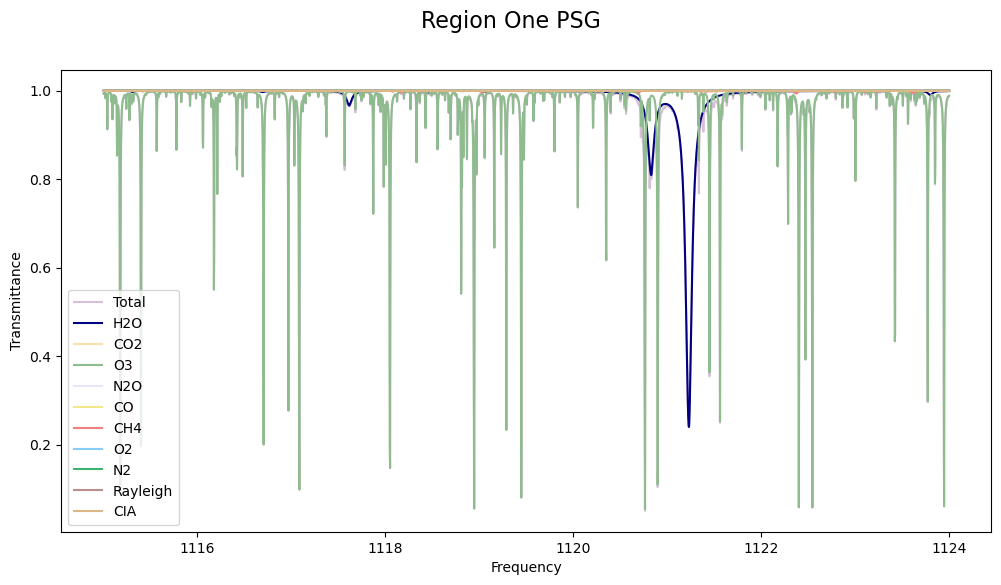

In [20]:
#setting variables, one is the PSG wavenumber, one is the composite spectrum, and the rest are the individual spectra that make up PSG's composite spectrum
R1_model_wavenumber = []
R1_total_spectrum = []
R1_H2O_spectrum = []
R1_CO2_spectrum = []
R1_O3_spectrum = []
R1_N2O_spectrum = []
R1_CO_spectrum = []
R1_CH4_spectrum = []
R1_O2_spectrum = []
R1_N2_spectrum = []
R1_Rayleigh_spectrum = []
R1_CIA_spectrum = []

#defining each variable with a row contained in the PSG .csv file
with open('/Users/physicsstudent2/desktop/venus_research/BSRI_2024/PSG/PSG TXT Files - R1_PSG addition.csv') as r1_psg_file:  
    plots = csv.reader(r1_psg_file, delimiter = ',') 
      
    for row in plots: 
        R1_model_wavenumber.append(float(row[0]))
        R1_total_spectrum.append(float(row[1]))
        R1_H2O_spectrum.append(float(row[2]))
        R1_CO2_spectrum.append(float(row[3]))
        R1_O3_spectrum.append(float(row[4]))
        R1_N2O_spectrum.append(float(row[5]))
        R1_CO_spectrum.append(float(row[6]))
        R1_CH4_spectrum.append(float(row[7]))
        R1_O2_spectrum.append(float(row[8]))
        R1_N2_spectrum.append(float(row[9]))
        R1_Rayleigh_spectrum.append(float(row[10]))
        R1_CIA_spectrum.append(float(row[11]))
        
#plotting the PSG model
fig, ax = plt.subplots(figsize=(12, 6))
plt.xlabel('Frequency')
plt.ylabel('Transmittance')
fig.suptitle('Region One PSG', fontsize=16)


ax.plot(R1_model_wavenumber,R1_total_spectrum, label = 'Total', color='thistle')
ax.plot(R1_model_wavenumber,R1_H2O_spectrum, label = 'H2O', color='navy')
ax.plot(R1_model_wavenumber,R1_CO2_spectrum, label = 'CO2', color='navajowhite')
ax.plot(R1_model_wavenumber,R1_O3_spectrum, label = 'O3', color='darkseagreen')
ax.plot(R1_model_wavenumber,R1_N2O_spectrum, label = 'N2O', color='lavender')
ax.plot(R1_model_wavenumber,R1_CO_spectrum, label = 'CO',  color='khaki')
ax.plot(R1_model_wavenumber,R1_CH4_spectrum, label = 'CH4', color='lightcoral')
ax.plot(R1_model_wavenumber,R1_O2_spectrum, label = 'O2', color='lightskyblue')
ax.plot(R1_model_wavenumber,R1_N2_spectrum, label = 'N2', color='mediumseagreen')
ax.plot(R1_model_wavenumber,R1_Rayleigh_spectrum, label = 'Rayleigh', color='rosybrown')
ax.plot(R1_model_wavenumber,R1_CIA_spectrum, label = 'CIA', color='burlywood')

plt.legend()

plt.show()        

In [21]:
TOOLTIPS = [ ("x","$x{‘00.00000000’}"),("y","$y{‘00.000’}"), ("strength", "$name")]
q = figure(title="Region One PSG",sizing_mode="stretch_width",
    height=500,tooltips=TOOLTIPS,
    x_axis_label="Wavenumber (cm^(-1))",
    y_axis_label="Intensity")

q.line(R1_model_wavenumber, R1_total_spectrum, legend_label='Earth', color='thistle') #consists of H2O, O3, N2O, and CH4
q.line(R1_model_wavenumber, R1_H2O_spectrum,legend_label='H2O', color='navy') #three features present
q.line(R1_model_wavenumber, R1_CO2_spectrum,legend_label='CO2', color='navajowhite')
q.line(R1_model_wavenumber, R1_O3_spectrum,legend_label='O3', color='darkseagreen') #primariliy present
q.line(R1_model_wavenumber, R1_N2O_spectrum,legend_label='N2O', color='lavender') #largely present
q.line(R1_model_wavenumber, R1_CO_spectrum,legend_label='CO', color='khaki') 
q.line(R1_model_wavenumber, R1_CH4_spectrum,legend_label='CH4', color='lightcoral') #present 
q.line(R1_model_wavenumber, R1_O2_spectrum,legend_label='O2', color='lightskyblue')
q.line(R1_model_wavenumber, R1_N2_spectrum,legend_label='N2', color='mediumseagreen')
q.line(R1_model_wavenumber, R1_Rayleigh_spectrum,legend_label='Rayleigh', color='rosybrown')
q.line(R1_model_wavenumber, R1_CIA_spectrum,legend_label='CIA', color='burlywood')


q.legend.location = "bottom_right"

show(q)



## R1 Candidate Molecules

In [22]:
SO2_candidate_wavenumber_shifted = []
SO2_candidate = []
O3_candidate_wavenumber_shifted = []
O3_candidate = []
H2O_candidate_wavenumber_shifted = []
H2O_candidate = []
CH4_candidate_wavenumber_shifted = []
CH4_candidate = []
NH3_candidate_wavenumber_shifted = []
NH3_candidate = []
PH3_candidate_wavenumber_shifted = []
PH3_candidate = []

with open('/Users/physicsstudent2/desktop/venus_research/BSRI_2024/PSG/PSG TXT Files - SO2.csv') as r1_psg_file:  
    plots = csv.reader(r1_psg_file, delimiter = ',') 
      
    for row in plots: 
        SO2_candidate_wavenumber_shifted.append(float(row[1]))
        SO2_candidate.append(float(row[2]))

with open('/Users/physicsstudent2/desktop/venus_research/BSRI_2024/PSG/PSG TXT Files - O3.csv') as r1_psg_file:  
    plots = csv.reader(r1_psg_file, delimiter = ',') 
      
    for row in plots: 
        O3_candidate_wavenumber_shifted.append(float(row[1]))
        O3_candidate.append(float(row[2]))
        
with open('/Users/physicsstudent2/desktop/venus_research/BSRI_2024/PSG/PSG TXT Files - H2O.csv') as r1_psg_file:  
    plots = csv.reader(r1_psg_file, delimiter = ',') 
      
    for row in plots: 
        H2O_candidate_wavenumber_shifted.append(float(row[1]))
        H2O_candidate.append(float(row[2]))
        
with open('/Users/physicsstudent2/desktop/venus_research/BSRI_2024/PSG/PSG TXT Files - CH4.csv') as r1_psg_file:  
    plots = csv.reader(r1_psg_file, delimiter = ',') 
      
    for row in plots: 
        CH4_candidate_wavenumber_shifted.append(float(row[1]))
        CH4_candidate.append(float(row[2]))
        
with open('/Users/physicsstudent2/desktop/venus_research/BSRI_2024/PSG/PSG TXT Files - NH3.csv') as r1_psg_file:  
    plots = csv.reader(r1_psg_file, delimiter = ',') 
      
    for row in plots: 
        PH3_candidate_wavenumber_shifted.append(float(row[1]))
        NH3_candidate.append(float(row[2]))

with open('/Users/physicsstudent2/desktop/venus_research/BSRI_2024/PSG/PSG TXT Files - PH3.csv') as r1_psg_file:  
    plots = csv.reader(r1_psg_file, delimiter = ',') 
      
    for row in plots: 
        PH3_candidate_wavenumber_shifted.append(float(row[1]))
        PH3_candidate.append(float(row[2]))

        
SO2_candidate_normalized = SO2_candidate / np.median(SO2_candidate)
O3_candidate_normalized = O3_candidate / np.median(O3_candidate)
H2O_candidate_normalized = H2O_candidate / np.median(H2O_candidate)
CH4_candidate_normalized = CH4_candidate / np.median(CH4_candidate)
NH3_candidate_normalized = NH3_candidate / np.median(NH3_candidate)
PH3_candidate_normalized = PH3_candidate / np.median(PH3_candidate)

# Data Processing

## Variables

In [23]:
R1_reversed = list(reversed(R1_model_wavenumber))

R1_H2O_reversed = list(reversed(R1_H2O_spectrum))
R1_O3_reversed = list(reversed(R1_O3_spectrum))
R1_N2O_reversed = list(reversed(R1_N2O_spectrum))
R1_CH4_reversed = list(reversed(R1_CH4_spectrum))

## File One

The following values must be adjusted based on the file you are processing. You can tell the spectrum is overly processed if a feature is spiking up above the normalized baseline of 1 in intensity. You can tell the spectrum is underprocessed if there are telluric features remaining in the spectrum (i.e. features that match the shape and depth of features present in the telluric spectrum). Mess with these values until these anomalies are minimized (it may be impossible to completely rid the spectrum of them). 

In [24]:
#normalizing the sky data
sky_normalized_1 = sky_1 / np.median(sky_1)

In [25]:
print(min(R1_H2O_reversed))
print(R1_H2O_reversed.index(0.239896))
print(R1_reversed[2786])

print(wavenumber_1[2150:2250])
print(min(sky_normalized_1[2150:2250]))

R1_exp_H2O_1 = np.log(min(sky_normalized_1[2150:2250]))/np.log(min(R1_H2O_reversed))
print(R1_exp_H2O_1)

0.239896
2786
1121.231634
[1121.0437 1121.0474 1121.0509 1121.0544 1121.058  1121.0616 1121.0652
 1121.0687 1121.0723 1121.0758 1121.0795 1121.083  1121.0865 1121.0901
 1121.0938 1121.0973 1121.1008 1121.1044 1121.1079 1121.1116 1121.1151
 1121.1187 1121.1222 1121.1259 1121.1294 1121.1329 1121.1365 1121.14
 1121.1437 1121.1472 1121.1508 1121.1543 1121.158  1121.1615 1121.165
 1121.1686 1121.1721 1121.1758 1121.1793 1121.1829 1121.1864 1121.1901
 1121.1936 1121.1971 1121.2007 1121.2042 1121.2079 1121.2114 1121.215
 1121.2185 1121.2222 1121.2257 1121.2292 1121.2328 1121.2363 1121.24
 1121.2435 1121.2471 1121.2506 1121.2543 1121.2578 1121.2614 1121.2649
 1121.2684 1121.2721 1121.2756 1121.2792 1121.2827 1121.2864 1121.2899
 1121.2935 1121.297  1121.3007 1121.3042 1121.3077 1121.3113 1121.3148
 1121.3185 1121.322  1121.3256 1121.3291 1121.3328 1121.3363 1121.3398
 1121.3434 1121.3469 1121.3506 1121.3541 1121.3577 1121.3612 1121.3649
 1121.3684 1121.3719 1121.3755 1121.3792 1121.3827 1121.3

In [26]:
print(min(R1_O3_reversed[2400:2500]))
print(R1_O3_reversed.index(0.951886))
print(R1_reversed[2414])

print(wavenumber_1[1850:1950])
print(min(sky_normalized_1[1850:1950]))

R1_exp_O3_1 = np.log(min(sky_normalized_1[1850:1950]))/np.log(min(R1_O3_reversed[2400:2500]))
print(R1_exp_O3_1)

0.951886
2414
1120.397748
[1120.2247 1120.2283 1120.2319 1120.2355 1120.239  1120.2426 1120.2461
 1120.2498 1120.2533 1120.2568 1120.2604 1120.2639 1120.2676 1120.2711
 1120.2747 1120.2782 1120.2817 1120.2854 1120.2889 1120.2925 1120.296
 1120.2996 1120.3032 1120.3068 1120.3103 1120.3138 1120.3174 1120.321
 1120.3246 1120.3281 1120.3317 1120.3352 1120.3389 1120.3424 1120.3459
 1120.3495 1120.353  1120.3567 1120.3602 1120.3638 1120.3673 1120.3708
 1120.3745 1120.3781 1120.3816 1120.3851 1120.3887 1120.3923 1120.3959
 1120.3994 1120.403  1120.4065 1120.4102 1120.4137 1120.4172 1120.4208
 1120.4243 1120.428  1120.4315 1120.4351 1120.4386 1120.4421 1120.4458
 1120.4493 1120.4529 1120.4564 1120.46   1120.4636 1120.4672 1120.4707
 1120.4742 1120.4778 1120.4814 1120.485  1120.4885 1120.4921 1120.4956
 1120.4993 1120.5028 1120.5063 1120.5099 1120.5134 1120.5171 1120.5206
 1120.5242 1120.5277 1120.5313 1120.5349 1120.5385 1120.542  1120.5455
 1120.5492 1120.5527 1120.5563 1120.5598 1120.5634 11

In [27]:
print(min(R1_N2O_reversed[3000:3400]))
print(R1_N2O_reversed.index(0.999323))
print(R1_reversed[3120])

print(wavenumber_1[2450:2550])
print(min(sky_normalized_1[2450:2550]))

R1_exp_N2O_1 = np.log(min(sky_normalized_1[2450:2550]))/np.log(min(R1_N2O_reversed[3000:3400]))
print(R1_exp_N2O_1)

0.999323
3120
1121.980866
[1121.8629 1121.8665 1121.87   1121.8735 1121.8772 1121.8807 1121.8843
 1121.8878 1121.8914 1121.895  1121.8986 1121.9021 1121.9056 1121.9093
 1121.9128 1121.9164 1121.9199 1121.9236 1121.9271 1121.9307 1121.9342
 1121.9379 1121.9414 1121.9449 1121.9485 1121.9521 1121.9557 1121.9592
 1121.9628 1121.9664 1121.97   1121.9735 1121.9771 1121.9807 1121.9843
 1121.9878 1121.9913 1121.995  1121.9985 1122.0021 1122.0056 1122.0092
 1122.0128 1122.0164 1122.0199 1122.0234 1122.0271 1122.0306 1122.0342
 1122.0377 1122.0414 1122.0449 1122.0485 1122.052  1122.0557 1122.0592
 1122.0627 1122.0663 1122.0699 1122.0735 1122.077  1122.0806 1122.0842
 1122.0878 1122.0913 1122.0948 1122.0985 1122.1021 1122.1056 1122.1091
 1122.1128 1122.1163 1122.1199 1122.1234 1122.1271 1122.1306 1122.1342
 1122.1377 1122.1414 1122.1449 1122.1484 1122.152  1122.1556 1122.1592
 1122.1627 1122.1663 1122.1699 1122.1735 1122.177  1122.1805 1122.1842
 1122.1877 1122.1913 1122.1948 1122.1985 1122.202  

In [34]:
print(min(R1_CH4_reversed[2900:3100]))
CH4_slice = R1_CH4_reversed[2900:3100]
print(CH4_slice.index(0.998182))
print(R1_CH4_reversed[3000])
print(R1_reversed[3296])

print(wavenumber_1[2500:2560])
#print(min(sky_normalized_1[2150:2250]))

#R1_exp_H2O_1 = np.log(min(sky_normalized_1[2150:2250]))/np.log(min(R1_H2O_reversed))
#print(R1_exp_H2O_1)

0.998182
16
0.999929
1122.375872
[1122.0414 1122.0449 1122.0485 1122.052  1122.0557 1122.0592 1122.0627
 1122.0663 1122.0699 1122.0735 1122.077  1122.0806 1122.0842 1122.0878
 1122.0913 1122.0948 1122.0985 1122.1021 1122.1056 1122.1091 1122.1128
 1122.1163 1122.1199 1122.1234 1122.1271 1122.1306 1122.1342 1122.1377
 1122.1414 1122.1449 1122.1484 1122.152  1122.1556 1122.1592 1122.1627
 1122.1663 1122.1699 1122.1735 1122.177  1122.1805 1122.1842 1122.1877
 1122.1913 1122.1948 1122.1985 1122.202  1122.2056 1122.2091 1122.2128
 1122.2163 1122.2198 1122.2234 1122.2271 1122.2306 1122.2341 1122.2377
 1122.2413 1122.2449 1122.2484 1122.252 ]


In [29]:
#R1_exp_H2O_1 = 0.3 #exponent on water transmission
#R1_exp_O3_1 = 0.575 #exponent on CO2 transmission
#R1_exp_N2O_1 = 0.3 #exponent on CH4 transmission
R1_exp_CH4_1 = 0.3 #exponent on CH4 transmission


R1_k_1 = 2 #Gaussian sigma of resolution broadening, in pixels

R1_wavenumber_shift_1 = 0.275 #empirical wavenumber shift to improve residuals

In [30]:
#multiplying the spectra by their respective exponents
R1_H2O_exp_1=[]
R1_O3_exp_1=[]
R1_N2O_exp_1=[]
R1_CH4_exp_1=[]
for number in R1_H2O_reversed:
    R1_H2O_exp_1.append(number**R1_exp_H2O)
for number in R1_O3_reversed:
    R1_O3_exp_1.append(number**R1_exp_O3)
for number in R1_N2O_reversed:
    R1_N2O_exp_1.append(number**R1_exp_N2O_1)
for number in R1_CH4_reversed:
    R1_CH4_exp_1.append(number**R1_exp_CH4_1)

#multiplying the exponentiated spectra together to create a new composite spectrum
R1_total_1 = np.array(R1_H2O_exp_1)*np.array(R1_O3_exp_1)*np.array(R1_N2O_exp_1)*np.array(R1_CH4_exp_1)

#gaussian smoothing the spectrum
R1_gaussian_1 = gaussian_filter(R1_total_1,R1_k_1)

#interpolating the spectrum over the wavenumber range
R1_interpolate_1 = scipy.interpolate.interp1d(R1_reversed, R1_gaussian_1)
R1_interpolate_function_1 = R1_interpolate_1(wavenumber_1)
R1_telluric_1 = shift(R1_interpolate_function_1, R1_wavenumber_shift_1)

#normalizing the model
R1_normalized_telluric_1 = R1_telluric_1 / np.median(R1_telluric_1)

NameError: name 'R1_exp_H2O' is not defined

In [ ]:
#sky division (dividing the data by the model) and normalization
R1_normalized_spectrum_1 = spectrum_1 / np.median(spectrum_1)
R1_processed_spectrum_1 = np.divide(R1_normalized_spectrum_1, R1_telluric_1)

In [ ]:
#plotting the processed file
TOOLTIPS = [ ("x","$x{‘00.00000000’}"),("y","$y{‘00.000’}"), ("strength", "$name")]
q = figure(title="File One",sizing_mode="stretch_width",
    height=500,tooltips=TOOLTIPS)

q.line(wavenumber_1, R1_normalized_telluric_1, legend_label='corrected telluric', color='orange')
q.line(wavenumber_1, R1_processed_spectrum_1, legend_label='venus processed', color='green')
q.line(wavenumber_1, R1_normalized_spectrum_1, legend_label='venus unprocessed', color='red')
q.line(wavenumber_1, sky_normalized_1,legend_label='sky', color='blue')

q.legend.location = "bottom_right"

show(q)

## File Two

In [ ]:
#R1_exp_H2O_2 = 0.3 #exponent on water transmission
#R1_exp_O3_2 = 0.575 #exponent on CO2 transmission
R1_exp_N2O_2 = 0.3 #exponent on CH4 transmission
R1_exp_CH4_2 = 0.3 #exponent on CH4 transmission

R1_k_2 = 2 #Gaussian sigma of resolution broadening, in pixels

R1_wavenumber_shift_2 = 0.275 #empirical wavenumber shift to improve residuals

In [ ]:
R1_H2O_exp_2=[]
R1_O3_exp_2=[]
R1_N2O_exp_2=[]
R1_CH4_exp_2=[]
for number in R1_H2O_reversed:
    R1_H2O_exp_2.append(number**R1_exp_H2O)
for number in R1_O3_reversed:
    R1_O3_exp_2.append(number**R1_exp_O3)
for number in R1_N2O_reversed:
    R1_N2O_exp_2.append(number**R1_exp_N2O_2)
for number in R1_CH4_reversed:
    R1_CH4_exp_2.append(number**R1_exp_CH4_2)
    
R1_total_2 = np.array(R1_H2O_exp_2)*np.array(R1_O3_exp_2)*np.array(R1_N2O_exp_2)*np.array(R1_CH4_exp_2)

R1_gaussian_2 = gaussian_filter(R1_total_2,R1_k_2)

R1_interpolate_2 = scipy.interpolate.interp1d(R1_reversed, R1_gaussian_2)
R1_interpolate_function_2 = R1_interpolate_2(wavenumber_2)

R1_telluric_2 = shift(R1_interpolate_function_2, R1_wavenumber_shift_2)
R1_normalized_telluric_2 = R1_telluric_2 / np.median(R1_telluric_2)

In [ ]:
R1_telluric_2 = shift(R1_interpolate_function_2, R1_wavenumber_shift_2)
R1_normalized_telluric_2 = R1_telluric_2 / np.median(R1_telluric_2)

R1_normalized_spectrum_2 = spectrum_2 / np.median(spectrum_2)
R1_processed_spectrum_2 = np.divide(R1_normalized_spectrum_2, R1_telluric_2)

sky_normalized_2 = sky_2 / np.median(sky_2)

In [ ]:
TOOLTIPS = [ ("x","$x{‘00.00000000’}"),("y","$y{‘00.000’}"), ("strength", "$name")]
q = figure(title="File Two",sizing_mode="stretch_width",
    height=500,tooltips=TOOLTIPS)

q.line(wavenumber_2, R1_normalized_telluric_2, legend_label='corrected telluric', color='orange')
q.line(wavenumber_2, R1_processed_spectrum_2, legend_label='venus processed', color='green')
q.line(wavenumber_2, R1_normalized_spectrum_2, legend_label='venus unprocessed', color='red')
q.line(wavenumber_2, sky_normalized_2,legend_label='sky', color='blue')

q.legend.location = "bottom_right"

show(q)

## File Three

In [ ]:
#R1_exp_H2O_3 = 0.3 #exponent on water transmission
#R1_exp_O3_3 = 0.575 #exponent on CO2 transmission
R1_exp_N2O_3 = 0.3 #exponent on CH4 transmission
R1_exp_CH4_3 = 0.3 #exponent on CH4 transmission

R1_k_3 = 2 #Gaussian sigma of resolution broadening, in pixels

R1_wavenumber_shift_3 = 0.275 #empirical wavenumber shift to improve residuals

In [ ]:
R1_H2O_exp_3=[]
R1_O3_exp_3=[]
R1_N2O_exp_3=[]
R1_CH4_exp_3=[]
for number in R1_H2O_reversed:
    R1_H2O_exp_3.append(number**R1_exp_H2O)
for number in R1_O3_reversed:
    R1_O3_exp_3.append(number**R1_exp_O3)
for number in R1_N2O_reversed:
    R1_N2O_exp_3.append(number**R1_exp_N2O_3)
for number in R1_CH4_reversed:
    R1_CH4_exp_3.append(number**R1_exp_CH4_3)
    
R1_total_3 = np.array(R1_H2O_exp_3)*np.array(R1_O3_exp_3)*np.array(R1_N2O_exp_3)*np.array(R1_CH4_exp_3)

R1_gaussian_3 = gaussian_filter(R1_total_3,R1_k_3)

R1_interpolate_3 = scipy.interpolate.interp1d(R1_reversed, R1_gaussian_3)
R1_interpolate_function_3 = R1_interpolate_3(wavenumber_3)

R1_telluric_3 = shift(R1_interpolate_function_3, R1_wavenumber_shift_3)
R1_normalized_telluric_3 = R1_telluric_3 / np.median(R1_telluric_3)

In [ ]:
R1_normalized_spectrum_3 = spectrum_3 / np.median(spectrum_3)
R1_processed_spectrum_3 = np.divide(R1_normalized_spectrum_3, R1_telluric_3)

sky_normalized_3 = sky_3 / np.median(sky_3)

In [ ]:
TOOLTIPS = [ ("x","$x{‘00.00000000’}"),("y","$y{‘00.000’}"), ("strength", "$name")]
q = figure(title="File Three",sizing_mode="stretch_width",
    height=500,tooltips=TOOLTIPS)

q.line(wavenumber_3, R1_normalized_telluric_3, legend_label='corrected telluric', color='orange')
q.line(wavenumber_3, R1_processed_spectrum_3, legend_label='venus processed', color='green')
q.line(wavenumber_3, R1_normalized_spectrum_3, legend_label='venus unprocessed', color='red')
q.line(wavenumber_3, sky_normalized_3,legend_label='sky', color='blue')

q.legend.location = "bottom_right"

show(q)

## File Four

In [ ]:
#R1_exp_H2O_4 = 0.3 #exponent on water transmission
#R1_exp_O3_4 = 0.55 #exponent on CO2 transmission
R1_exp_N2O_4 = 0.3 #exponent on CH4 transmission
R1_exp_CH4_4 = 0.4 #exponent on CH4 transmission

R1_k_4 = 2 #Gaussian sigma of resolution broadening, in pixels

R1_wavenumber_shift_4 = 0.275 #empirical wavenumber shift to improve residuals

In [ ]:
R1_H2O_exp_4=[]
R1_O3_exp_4=[]
R1_N2O_exp_4=[]
R1_CH4_exp_4=[]
for number in R1_H2O_reversed:
    R1_H2O_exp_4.append(number**R1_exp_H2O)
for number in R1_O3_reversed:
    R1_O3_exp_4.append(number**R1_exp_O3)
for number in R1_N2O_reversed:
    R1_N2O_exp_4.append(number**R1_exp_N2O_4)
for number in R1_CH4_reversed:
    R1_CH4_exp_4.append(number**R1_exp_CH4_4)
    
R1_total_4 = np.array(R1_H2O_exp_4)*np.array(R1_O3_exp_4)*np.array(R1_N2O_exp_4)*np.array(R1_CH4_exp_4)

R1_gaussian_4 = gaussian_filter(R1_total_4,R1_k_4)

R1_interpolate_4 = scipy.interpolate.interp1d(R1_reversed, R1_gaussian_4)
R1_interpolate_function_4 = R1_interpolate_4(wavenumber_4)

R1_telluric_4 = shift(R1_interpolate_function_4, R1_wavenumber_shift_4)
R1_normalized_telluric_4 = R1_telluric_4 / np.median(R1_telluric_4)

In [ ]:
R1_normalized_spectrum_4 = spectrum_4 / np.median(spectrum_4)
R1_processed_spectrum_4 = np.divide(R1_normalized_spectrum_4, R1_telluric_4)

sky_normalized_4 = sky_4 / np.median(sky_4)

In [ ]:
TOOLTIPS = [ ("x","$x{‘00.00000000’}"),("y","$y{‘00.000’}"), ("strength", "$name")]
q = figure(title="File Four",sizing_mode="stretch_width",
    height=500,tooltips=TOOLTIPS)

q.line(wavenumber_4, R1_normalized_telluric_4, legend_label='corrected telluric', color='orange')
q.line(wavenumber_4, R1_processed_spectrum_4, legend_label='venus processed', color='green')
q.line(wavenumber_4, R1_normalized_spectrum_4, legend_label='venus unprocessed', color='red')
q.line(wavenumber_4, sky_normalized_4,legend_label='sky', color='blue')

q.legend.location = "bottom_right"

show(q)

## File Five

In [ ]:
#R1_exp_H2O_5 = 0.3 #exponent on water transmission
#R1_exp_O3_5 = 0.55 #exponent on CO2 transmission
R1_exp_N2O_5 = 0.3 #exponent on CH4 transmission
R1_exp_CH4_5 = 0.3 #exponent on CH4 transmission

R1_k_5 = 2 #Gaussian sigma of resolution broadening, in pixels

R1_wavenumber_shift_5 = 0.275 #empirical wavenumber shift to improve residuals

In [ ]:
R1_H2O_exp_5=[]
R1_O3_exp_5=[]
R1_N2O_exp_5=[]
R1_CH4_exp_5=[]
for number in R1_H2O_reversed:
    R1_H2O_exp_5.append(number**R1_exp_H2O)
for number in R1_O3_reversed:
    R1_O3_exp_5.append(number**R1_exp_O3)
for number in R1_N2O_reversed:
    R1_N2O_exp_5.append(number**R1_exp_N2O_5)
for number in R1_CH4_reversed:
    R1_CH4_exp_5.append(number**R1_exp_CH4_5)
    
R1_total_5 = np.array(R1_H2O_exp_5)*np.array(R1_O3_exp_5)*np.array(R1_N2O_exp_5)*np.array(R1_CH4_exp_5)

R1_gaussian_5 = gaussian_filter(R1_total_5,R1_k_5)

R1_interpolate_5 = scipy.interpolate.interp1d(R1_reversed, R1_gaussian_5)
R1_interpolate_function_5 = R1_interpolate_5(wavenumber_5)

R1_telluric_5 = shift(R1_interpolate_function_5, R1_wavenumber_shift_5)
R1_normalized_telluric_5 = R1_telluric_5 / np.median(R1_telluric_5)

In [ ]:
R1_normalized_spectrum_5 = spectrum_5 / np.median(spectrum_5)
R1_processed_spectrum_5 = np.divide(R1_normalized_spectrum_5, R1_telluric_5)

sky_normalized_5 = sky_5 / np.median(sky_5)

In [ ]:
TOOLTIPS = [ ("x","$x{‘00.00000000’}"),("y","$y{‘00.000’}"), ("strength", "$name")]
q = figure(title="File Five",sizing_mode="stretch_width",
    height=500,tooltips=TOOLTIPS)

q.line(wavenumber_5, R1_normalized_telluric_5, legend_label='corrected telluric', color='orange')
q.line(wavenumber_5, R1_processed_spectrum_5, legend_label='venus processed', color='green')
q.line(wavenumber_5, R1_normalized_spectrum_5, legend_label='venus unprocessed', color='red')
q.line(wavenumber_5, sky_normalized_5,legend_label='sky', color='blue')

q.legend.location = "bottom_right"

show(q)

## File Six

In [ ]:
#R1_exp_H2O_6 = 0.3 #exponent on water transmission
#R1_exp_O3_6 = 0.5 #exponent on CO2 transmission
R1_exp_N2O_6 = 0.3 #exponent on CH4 transmission
R1_exp_CH4_6 = 0.3 #exponent on CH4 transmission

R1_k_6 = 2 #Gaussian sigma of resolution broadening, in pixels

R1_wavenumber_shift_6 = 0.275 #empirical wavenumber shift to improve residuals

In [ ]:
R1_H2O_exp_6=[]
R1_O3_exp_6=[]
R1_N2O_exp_6=[]
R1_CH4_exp_6=[]
for number in R1_H2O_reversed:
    R1_H2O_exp_6.append(number**R1_exp_H2O)
for number in R1_O3_reversed:
    R1_O3_exp_6.append(number**R1_exp_O3)
for number in R1_N2O_reversed:
    R1_N2O_exp_6.append(number**R1_exp_N2O_6)
for number in R1_CH4_reversed:
    R1_CH4_exp_6.append(number**R1_exp_CH4_6)
    
R1_total_6 = np.array(R1_H2O_exp_6)*np.array(R1_O3_exp_6)*np.array(R1_N2O_exp_6)*np.array(R1_CH4_exp_6)

R1_gaussian_6 = gaussian_filter(R1_total_6,R1_k_6)

R1_interpolate_6 = scipy.interpolate.interp1d(R1_reversed, R1_gaussian_6)
R1_interpolate_function_6 = R1_interpolate_6(wavenumber_6)

R1_telluric_6 = shift(R1_interpolate_function_6, R1_wavenumber_shift_6)
R1_normalized_telluric_6 = R1_telluric_6 / np.median(R1_telluric_6)

In [ ]:
R1_normalized_spectrum_6 = spectrum_6 / np.median(spectrum_6)
R1_processed_spectrum_6 = np.divide(R1_normalized_spectrum_6, R1_telluric_6)

sky_normalized_6 = sky_6 / np.median(sky_6)

In [ ]:
TOOLTIPS = [ ("x","$x{‘00.00000000’}"),("y","$y{‘00.000’}"), ("strength", "$name")]
q = figure(title="File Six",sizing_mode="stretch_width",
    height=500,tooltips=TOOLTIPS)

q.line(wavenumber_6, R1_normalized_telluric_6, legend_label='corrected telluric', color='orange')
q.line(wavenumber_6, R1_processed_spectrum_6, legend_label='venus processed', color='green')
q.line(wavenumber_6, R1_normalized_spectrum_6, legend_label='venus unprocessed', color='red')
q.line(wavenumber_6, sky_normalized_6,legend_label='sky', color='blue')

q.legend.location = "bottom_right"

show(q)

## File Seven

In [ ]:
#R1_exp_H2O_7 = 0.1 #exponent on water transmission
#R1_exp_O3_7 = 0.5 #exponent on CO2 transmission
R1_exp_N2O_7 = 0.3 #exponent on CH4 transmission
R1_exp_CH4_7 = 0.3 #exponent on CH4 transmission

R1_k_7 = 2 #Gaussian sigma of resolution broadening, in pixels

R1_wavenumber_shift_7 = 0.275 #empirical wavenumber shift to improve residuals

In [ ]:
R1_H2O_exp_7=[]
R1_O3_exp_7=[]
R1_N2O_exp_7=[]
R1_CH4_exp_7=[]
for number in R1_H2O_reversed:
    R1_H2O_exp_7.append(number**R1_exp_H2O)
for number in R1_O3_reversed:
    R1_O3_exp_7.append(number**R1_exp_O3)
for number in R1_N2O_reversed:
    R1_N2O_exp_7.append(number**R1_exp_N2O_7)
for number in R1_CH4_reversed:
    R1_CH4_exp_7.append(number**R1_exp_CH4_7)
    
R1_total_7 = np.array(R1_H2O_exp_7)*np.array(R1_O3_exp_7)*np.array(R1_N2O_exp_7)*np.array(R1_CH4_exp_7)

R1_gaussian_7 = gaussian_filter(R1_total_7,R1_k_7)

R1_interpolate_7 = scipy.interpolate.interp1d(R1_reversed, R1_gaussian_7)
R1_interpolate_function_7 = R1_interpolate_7(wavenumber_7)

R1_telluric_7 = shift(R1_interpolate_function_7, R1_wavenumber_shift_7)
R1_normalized_telluric_7 = R1_telluric_7 / np.median(R1_telluric_7)

In [ ]:
R1_normalized_spectrum_7 = spectrum_7 / np.median(spectrum_7)
R1_processed_spectrum_7 = np.divide(R1_normalized_spectrum_7, R1_telluric_7)

sky_normalized_7 = sky_7 / np.median(sky_7)

In [ ]:
TOOLTIPS = [ ("x","$x{‘00.00000000’}"),("y","$y{‘00.000’}"), ("strength", "$name")]
q = figure(title="File Seven",sizing_mode="stretch_width",
    height=500,tooltips=TOOLTIPS)

q.line(wavenumber_7, R1_normalized_telluric_7, legend_label='corrected telluric', color='orange')
q.line(wavenumber_7, R1_processed_spectrum_7, legend_label='venus processed', color='green')
q.line(wavenumber_7, R1_normalized_spectrum_7, legend_label='venus unprocessed', color='red')
q.line(wavenumber_7, sky_normalized_7,legend_label='sky', color='blue')

q.legend.location = "bottom_right"

show(q)

## File Eight

In [ ]:
R1_exp_H2O_8 = 0.3 #exponent on water transmission
R1_exp_O3_8 = 0.5 #exponent on CO2 transmission
R1_exp_N2O_8 = 0.3 #exponent on CH4 transmission
R1_exp_CH4_8 = 0.3 #exponent on CH4 transmission

R1_k_8 = 2 #Gaussian sigma of resolution broadening, in pixels

R1_wavenumber_shift_8 = 0.275 #empirical wavenumber shift to improve residuals

In [ ]:
R1_H2O_exp_8=[]
R1_O3_exp_8=[]
R1_N2O_exp_8=[]
R1_CH4_exp_8=[]
for number in R1_H2O_reversed:
    R1_H2O_exp_8.append(number**R1_exp_H2O_8)
for number in R1_O3_reversed:
    R1_O3_exp_8.append(number**R1_exp_O3_8)
for number in R1_N2O_reversed:
    R1_N2O_exp_8.append(number**R1_exp_N2O_8)
for number in R1_CH4_reversed:
    R1_CH4_exp_8.append(number**R1_exp_CH4_8)
    
R1_total_8 = np.array(R1_H2O_exp_8)*np.array(R1_O3_exp_8)*np.array(R1_N2O_exp_8)*np.array(R1_CH4_exp_8)

R1_gaussian_8 = gaussian_filter(R1_total_8,R1_k_8)

R1_interpolate_8 = scipy.interpolate.interp1d(R1_reversed, R1_gaussian_8)
R1_interpolate_function_8 = R1_interpolate_8(wavenumber_8)

R1_telluric_8 = shift(R1_interpolate_function_8, R1_wavenumber_shift_8)
R1_normalized_telluric_8 = R1_telluric_8 / np.median(R1_telluric_8)

In [ ]:
R1_normalized_spectrum_8 = spectrum_8 / np.median(spectrum_8)
R1_processed_spectrum_8 = np.divide(R1_normalized_spectrum_8, R1_telluric_8)

sky_normalized_8 = sky_8 / np.median(sky_8)

In [ ]:
TOOLTIPS = [ ("x","$x{‘00.00000000’}"),("y","$y{‘00.000’}"), ("strength", "$name")]
q = figure(title="File Eight",sizing_mode="stretch_width",
    height=500,tooltips=TOOLTIPS)

q.line(wavenumber_8, R1_normalized_telluric_8, legend_label='corrected telluric', color='orange')
q.line(wavenumber_8, R1_processed_spectrum_8, legend_label='venus processed', color='green')
q.line(wavenumber_8, R1_normalized_spectrum_8, legend_label='venus unprocessed', color='red')
q.line(wavenumber_8, sky_normalized_8,legend_label='sky', color='blue')

q.legend.location = "bottom_right"

show(q)

## File Nine

In [ ]:
R1_exp_H2O_9 = 0.45 #exponent on water transmission
R1_exp_O3_9 = 0.55 #exponent on CO2 transmission
R1_exp_N2O_9 = 0.3 #exponent on CH4 transmission
R1_exp_CH4_9 = 0.3 #exponent on CH4 transmission

R1_k_9 = 2 #Gaussian sigma of resolution broadening, in pixels

R1_wavenumber_shift_9 = 0.275 #empirical wavenumber shift to improve residuals

In [ ]:
R1_H2O_exp_9=[]
R1_O3_exp_9=[]
R1_N2O_exp_9=[]
R1_CH4_exp_9=[]
for number in R1_H2O_reversed:
    R1_H2O_exp_9.append(number**R1_exp_H2O_9)
for number in R1_O3_reversed:
    R1_O3_exp_9.append(number**R1_exp_O3_9)
for number in R1_N2O_reversed:
    R1_N2O_exp_9.append(number**R1_exp_N2O_9)
for number in R1_CH4_reversed:
    R1_CH4_exp_9.append(number**R1_exp_CH4_9)
    
R1_total_9 = np.array(R1_H2O_exp_9)*np.array(R1_O3_exp_9)*np.array(R1_N2O_exp_9)*np.array(R1_CH4_exp_9)

R1_gaussian_9 = gaussian_filter(R1_total_9,R1_k_9)

R1_interpolate_9 = scipy.interpolate.interp1d(R1_reversed, R1_gaussian_9)
R1_interpolate_function_9 = R1_interpolate_9(wavenumber_9)

R1_telluric_9 = shift(R1_interpolate_function_9, R1_wavenumber_shift_9)
R1_normalized_telluric_9 = R1_telluric_9 / np.median(R1_telluric_9)

In [ ]:
R1_normalized_spectrum_9 = spectrum_9 / np.median(spectrum_9)
R1_processed_spectrum_9 = np.divide(R1_normalized_spectrum_9, R1_telluric_9)

sky_normalized_9 = sky_9 / np.median(sky_9)

In [ ]:
TOOLTIPS = [ ("x","$x{‘00.00000000’}"),("y","$y{‘00.000’}"), ("strength", "$name")]
q = figure(title="File Nine",sizing_mode="stretch_width",
    height=500,tooltips=TOOLTIPS)

q.line(wavenumber_9, R1_normalized_telluric_9, legend_label='corrected telluric', color='orange')
q.line(wavenumber_9, R1_processed_spectrum_9, legend_label='venus processed', color='green')
q.line(wavenumber_9, R1_normalized_spectrum_9, legend_label='venus unprocessed', color='red')
q.line(wavenumber_9, sky_normalized_9,legend_label='sky', color='blue')

q.legend.location = "bottom_right"

show(q)

## Average, Doppler Shift, Fit to Polynomial, Plot

In [ ]:
#averaging all the pieces together
average_processed_spectrum = (R1_processed_spectrum_1 + R1_processed_spectrum_2 + R1_processed_spectrum_3 + R1_processed_spectrum_4+ R1_processed_spectrum_5 + R1_processed_spectrum_6 + R1_processed_spectrum_7 + R1_processed_spectrum_8 + R1_processed_spectrum_9) / 9 
average_unprocessed_spectrum = (R1_normalized_spectrum_1 + R1_normalized_spectrum_2 + R1_normalized_spectrum_3 + R1_normalized_spectrum_4 + R1_normalized_spectrum_5 + R1_normalized_spectrum_6 + R1_normalized_spectrum_7 + R1_normalized_spectrum_8 + R1_normalized_spectrum_9) / 9 
average_sky = (sky_normalized_1 + sky_normalized_2 + sky_normalized_3 + sky_normalized_4 + sky_normalized_5 + sky_normalized_6 + sky_normalized_7 + sky_normalized_8 + sky_normalized_9) / 9
average_telluric = (R1_normalized_telluric_1 + R1_normalized_telluric_2 + R1_normalized_telluric_3 + R1_normalized_telluric_4 + R1_normalized_telluric_5 + R1_normalized_telluric_6 + R1_normalized_telluric_7 + R1_normalized_telluric_8 + R1_normalized_telluric_9) / 9
average_wavenumber = (wavenumber_1 + wavenumber_2 + wavenumber_3 + wavenumber_4 + wavenumber_5 + wavenumber_6 + wavenumber_7 + wavenumber_8 + wavenumber_9) / 9

In [ ]:
#adding doppler shift to the wavenumbers
average_wavenumber_ds=[]
for number in average_wavenumber:
    average_wavenumber_ds.append(number+0.03)

In [ ]:
#plotting average spectrum, can also plot them doppler shifted by changing average_wavenumber to average_wavenumber_ds
TOOLTIPS = [ ("x","$x{‘00.00000000’}"),("y","$y{‘00.000’}"), ("strength", "$name")]
q = figure(title="Average Spectrum",sizing_mode="stretch_width",
    height=500,tooltips=TOOLTIPS,
    x_axis_label="Wavenumber (cm^(-1))",
    y_axis_label="Intensity")

#q.line(average_wavenumber, average_processed_spectrum, legend_label='average processed venus', color='green')
q.line(average_wavenumber, average_processed_spectrum, legend_label='Average Processed Venus', color='red')
#q.line(average_wavenumber, average_unprocessed_spectrum, legend_label='Average Unprocessed Venus', color='blue')
q.line(average_wavenumber, average_sky,legend_label='average sky', color='blue')
q.line(average_wavenumber, average_telluric, legend_label='Corrected Telluric', color='green')

#q.x_range = Range1d(1120, 1121)
#q.y_range = Range1d(0.5, 1)

q.legend.location = "bottom_right"

show(q)

# Line-by-Line Load In

## for marking underprocessed telluric features

In [ ]:
#import line by line (assuming gathered from HITRAN)
df=pd.read_fwf('/Users/physicsstudent2/desktop/venus_research/Venus_Data_Confidential/line_by_lines/H2O_all.txt',header=None) 
wn=df.loc[:,1]
abund=df.loc[:,2]
split_df=pd.concat([wn,abund],axis=1)
split_array=split_df.to_numpy()
#print(split_array)

#get desired wavenumbers

mol_lambda1=[]
abund_lambda1=[]
for a in range(0,len(split_array),1):
    #if split_array[a,0] > 1114.7114576040406 and split_array[a,0] < 1123.696475590839:
    if split_array[a,0] > 1121 and split_array[a,0] < 1123:
        if split_array[a,1] > 1e-23: # and split_array[a,1] < 1e-22: #remove the and for the regular limit
            mol_lambda1.append(split_array[a,0]) #get list of wavenumber locations
            abund_lambda1.append(split_array[a,1]) # get corresponding strengths

print(len(mol_lambda1))
range1_array=np.stack((mol_lambda1, abund_lambda1),axis=-1) #make locations and strengths one array
line_locations_region_1 = np.array(mol_lambda1) #make it match previous naming structure

In [ ]:
#import line by line (assuming gathered from HITRAN)
df=pd.read_fwf('/Users/physicsstudent2/desktop/venus_research/Venus_Data_Confidential/line_by_lines/O3_all.txt',header=None) 
wn=df.loc[:,1]
abund=df.loc[:,2]
split_df=pd.concat([wn,abund],axis=1)
split_array=split_df.to_numpy()
#print(split_array)

#get desired wavenumbers

#Region 1:
two_mol_lambda1=[]
two_abund_lambda1=[]
for a in range(0,len(split_array),1):
    #if split_array[a,0] > 1114.7114576040406 and split_array[a,0] < 1123.696475590839:
    if split_array[a,0] > 1117 and split_array[a,0] < 1118 or split_array[a,0] > 1119 and split_array[a,0] < 1119.33:
        if split_array[a,1] > 1e-21: # and split_array[a,1] < 1e-22: #remove the and for the regular limit
            two_mol_lambda1.append(split_array[a,0]) #get list of wavenumber locations
            two_abund_lambda1.append(split_array[a,1]) # get corresponding strengths

print(len(two_mol_lambda1))
two_range1_array=np.stack((two_mol_lambda1, two_abund_lambda1),axis=-1) #make locations and strengths one array
two_line_locations_region_1 = np.array(two_mol_lambda1) #make it match previous naming structure

## for data analysis

In [ ]:
#import line by line (assuming gathered from HITRAN)
df=pd.read_fwf('/Users/physicsstudent2/desktop/venus_research/Venus_Data_Confidential/line_by_lines/SO2_all_iso.txt',header=None) 
wn=df.loc[:,1]
abund=df.loc[:,2]
split_df=pd.concat([wn,abund],axis=1)
split_array=split_df.to_numpy()
#print(split_array)

#get desired wavenumbers

#Region 1:
three_mol_lambda1=[]
three_abund_lambda1=[]
for a in range(0,len(split_array),1):
    if split_array[a,0] > 1114.7114576040406 and split_array[a,0] < 1123.696475590839:
    #if split_array[a,0] > 1117 and split_array[a,0] < 1118 or split_array[a,0] > 1119 and split_array[a,0] < 1119.33:
        if split_array[a,1] > 1e-21: # and split_array[a,1] < 1e-22: #remove the and for the regular limit
            three_mol_lambda1.append(split_array[a,0]) #get list of wavenumber locations
            three_abund_lambda1.append(split_array[a,1]) # get corresponding strengths

print(len(three_mol_lambda1))
three_range1_array=np.stack((three_mol_lambda1, three_abund_lambda1),axis=-1) #make locations and strengths one array
three_line_locations_region_1 = np.array(three_mol_lambda1) #make it match previous naming structure

In [ ]:
exp_SO2_hitran = 0.01 #exponent on SO2 
k_SO2_hitran = 20 #Gaussian sigma of resolution broadening, in pixels
wavenumber_shift_SO2_hitran = 0 #empirical wavenumber shift to improve residuals

SO2_hitran_total=[]
for number in abund:
    SO2_hitran_total.append(number**exp_SO2_hitran)


SO2_hitran_gaussian = gaussian_filter(SO2_hitran_total,k_SO2_hitran)

SO2_hitran_interpolate = scipy.interpolate.interp1d(wn, SO2_hitran_gaussian)
SO2_hitran_interpolate_function = SO2_hitran_interpolate(average_wavenumber)

SO2_hitran_processed = shift(SO2_hitran_interpolate_function, wavenumber_shift_SO2_hitran)
SO2_hitran_processed_normalized = SO2_hitran_processed / np.median(SO2_hitran_processed)

# Cross Sections

In [ ]:
SO2_cross_section_wavenumber=[]
SO2_cross_section=[]

with open('/Users/physicsstudent2/desktop/venus_research/Venus_Data_Confidential/cross_sections/SO2_cross_section.csv') as cross_section_file:  
    plots = csv.reader(cross_section_file, delimiter = ',') 
      
    for row in plots: 
        SO2_cross_section_wavenumber.append(float(row[0]))
        SO2_cross_section.append(float(row[1]))
        
SO2_cross_section_normalized = SO2_cross_section / np.median(SO2_cross_section)

exp_SO2_cross_section = 0.01 #exponent on SO2 
k_SO2_cross_section = 2 #Gaussian sigma of resolution broadening, in pixels
wavenumber_shift_SO2_cross_section = 0 #empirical wavenumber shift to improve residuals

SO2_cross_section_total=[]
for number in SO2_cross_section_normalized:
    SO2_cross_section_total.append(number**exp_SO2_cross_section)


SO2_cross_section_gaussian = gaussian_filter(SO2_cross_section_total,k_SO2_cross_section)

SO2_cross_section_interpolate = scipy.interpolate.interp1d(SO2_cross_section_wavenumber, SO2_cross_section_gaussian)
SO2_cross_section_interpolate_function = SO2_cross_section_interpolate(average_wavenumber)

SO2_cross_section_processed = shift(SO2_cross_section_interpolate_function, wavenumber_shift_SO2_cross_section)
SO2_cross_section_processed_normalized = SO2_cross_section_processed / np.median(SO2_cross_section_processed)

# Separating and Cutting Orders

In [ ]:
#inputting nans into the areas of the spectrum where the orders overlap
average_processed_spectrum[182:340] = np.nan 
average_processed_spectrum[438:596] = np.nan 
average_processed_spectrum[694:852] = np.nan
average_processed_spectrum[950:1108] = np.nan
average_processed_spectrum[1206:1364] = np.nan
average_processed_spectrum[1462:1620] = np.nan
average_processed_spectrum[1718:1876] = np.nan
average_processed_spectrum[1974:2132] = np.nan
average_processed_spectrum[2230:2388] = np.nan

#setting gap ranges to these nan values
gap_ranges = [(average_wavenumber_ds[182],average_wavenumber_ds[340]), (average_wavenumber_ds[438], average_wavenumber_ds[596]), (average_wavenumber_ds[694], average_wavenumber_ds[852]), (average_wavenumber_ds[950], average_wavenumber_ds[1108]), (average_wavenumber_ds[1206], average_wavenumber_ds[1364]), (average_wavenumber_ds[1462], average_wavenumber_ds[1620]), (average_wavenumber_ds[1718], average_wavenumber_ds[1876]), (average_wavenumber_ds[1974], average_wavenumber_ds[2132]), (average_wavenumber_ds[2230], average_wavenumber_ds[2388])]

In [ ]:
TOOLTIPS = [ ("x","$x{‘00.00000000’}"),("y","$y{‘00.000’}"), ("strength", "$name")]
q = figure(title="Average Spectrum with Cut Orders",sizing_mode="stretch_width",
    height=500,tooltips=TOOLTIPS,
    x_axis_label="Wavenumber (cm^(-1))",
    y_axis_label="Intensity")

average_processed_spectrum[182:340] = np.nan 
average_processed_spectrum[438:596] = np.nan 
average_processed_spectrum[694:852] = np.nan
average_processed_spectrum[950:1108] = np.nan
average_processed_spectrum[1206:1364] = np.nan
average_processed_spectrum[1462:1620] = np.nan
average_processed_spectrum[1718:1876] = np.nan
average_processed_spectrum[1974:2132] = np.nan
average_processed_spectrum[2230:2388] = np.nan

gap_ranges = [(average_wavenumber_ds[182],average_wavenumber_ds[340]), (average_wavenumber_ds[438], average_wavenumber_ds[596]), (average_wavenumber_ds[694], average_wavenumber_ds[852]), (average_wavenumber_ds[950], average_wavenumber_ds[1108]), (average_wavenumber_ds[1206], average_wavenumber_ds[1364]), (average_wavenumber_ds[1462], average_wavenumber_ds[1620]), (average_wavenumber_ds[1718], average_wavenumber_ds[1876]), (average_wavenumber_ds[1974], average_wavenumber_ds[2132]), (average_wavenumber_ds[2230], average_wavenumber_ds[2388])]

#q.line(average_wavenumber[1:181],average_processed_spectrum[1:181], legend_label='average processed venus', color='red')
#q.line(average_wavenumber[341:437],average_processed_spectrum[341:437], color='red')
#q.line(average_wavenumber[597:693],average_processed_spectrum[597:693], color='red')
#q.line(average_wavenumber[853:949],average_processed_spectrum[855:949], color='red')
#q.line(average_wavenumber[1109:1205],average_processed_spectrum[1109:1205], color='red')
#q.line(average_wavenumber[1365:1461],average_processed_spectrum[1365:1461], color='red')
#q.line(average_wavenumber[1621:1717],average_processed_spectrum[1621:1717], color='red')
#q.line(average_wavenumber[1877:1973],average_processed_spectrum[1877:1973], color='red')
#q.line(average_wavenumber[2133:2229],average_processed_spectrum[2133:2229], color='red')
#q.line(average_wavenumber[2389:2560],average_processed_spectrum[2389:2560], color='red')

q.line(average_wavenumber_ds[1:181],average_processed_spectrum[1:181], legend_label='Average Processed Venus', color='red')
q.line(average_wavenumber_ds[341:437],average_processed_spectrum[341:437], color='red')
q.line(average_wavenumber_ds[597:693],average_processed_spectrum[597:693], color='red')
q.line(average_wavenumber_ds[853:949],average_processed_spectrum[855:949], color='red')
q.line(average_wavenumber_ds[1109:1205],average_processed_spectrum[1109:1205], color='red')
q.line(average_wavenumber_ds[1365:1461],average_processed_spectrum[1365:1461], color='red')
q.line(average_wavenumber_ds[1621:1717],average_processed_spectrum[1621:1717], color='red')
q.line(average_wavenumber_ds[1877:1973],average_processed_spectrum[1877:1973], color='red')
q.line(average_wavenumber_ds[2133:2229],average_processed_spectrum[2133:2229], color='red')
q.line(average_wavenumber_ds[2389:2560],average_processed_spectrum[2389:2560], color='red')
#q.line(average_wavenumber[1:181],average_sky[1:181], legend_label='Average Sky', color='green')
#q.line(average_wavenumber[341:437],average_sky[341:437],color='green')
#q.line(average_wavenumber[597:693],average_sky[597:693], color='green')
#q.line(average_wavenumber[853:949],average_sky[855:949], color='green')
#q.line(average_wavenumber[1109:1205],average_sky[1109:1205], color='green')
#q.line(average_wavenumber[1365:1461],average_sky[1365:1461], color='green')
#q.line(average_wavenumber[1621:1717],average_sky[1621:1717], color='green')
#q.line(average_wavenumber[1877:1973],average_sky[1877:1973], color='green')
#q.line(average_wavenumber[2133:2229],average_sky[2133:2229], color='green')
#q.line(average_wavenumber[2389:2560],average_sky[2389:2560], color='green')
#q.line(average_wavenumber, SO2_cross_section_processed_normalized,legend_label='SO2', color='cyan')
#q.line(average_wavenumber, SO2_hitran_processed_normalized,legend_label='SO2', color='black')

for start, end in gap_ranges:
    box = BoxAnnotation(left=start, right=end, fill_alpha=0.3, fill_color='gray')
    q.add_layout(box)
#dummy = q.rect(x=[], y=[], width=0, height=0, fill_color='red', fill_alpha=0.3, legend_label="cut orders")

#for marking strong telluric features
for place in range(0,len(line_locations_region_1)):
    q.line([range1_array[place,0]+0.03,range1_array[place,0]+0.03], [1.06,0.60],color='black',line_width=1,name=str(range1_array[place,1]), legend_label='Strong Telluric Features That Cannot Be Fully Processed')
for place in range(0,len(two_line_locations_region_1)):
    q.line([two_range1_array[place,0]+0.03,two_range1_array[place,0]+0.03], [1.06,0.60],color='black',line_width=1,name=str(two_range1_array[place,1]))

#for data analysis
#for place in range(0,len(three_line_locations_region_1)):
    #q.line([three_range1_array[place,0],three_range1_array[place,0]], [1.1,0.60],color='gray',line_width=1,name=str(three_range1_array[place,1]))
    
#q.x_range = Range1d(1120.7, 1121.9)
#q.y_range = Range1d(0.5, 1)
    
q.legend.location = "bottom_right"

show(q)

# Fitting to Polynomial

In [ ]:
np.set_printoptions(threshold=sys.maxsize)

mask = np.ones(len(average_wavenumber_ds), dtype=bool)

keep = [
    (1, 181),
    (341, 437),
    (597, 693),
    (853, 949),
    (1109, 1205),
    (1365, 1461),
    (1621, 1717),
    (1877, 1973),
    (2133, 2229),
    (2389, 2560)
]

for start, end in keep:
    mask[start:end] = False

masked_wavenumber = np.ma.masked_array(average_wavenumber_ds, mask=mask)
masked_spectrum = np.ma.masked_array(average_processed_spectrum, mask=mask)

#print(average_wavenumber_ds)
#print(masked_wavenumber)
#print(masked_spectrum)

In [ ]:
class KnotSplineModel(object):
    """
    This uses a B-spline of n degree, which is a a piecewise polynomial function of degree n that is defined by a set of control points and a set of knots. The knots parameter
    specifies the number of INTERIOR knots to use for the fit.

    * Inspired by PyModelFit UniformCDFKnotSplineModel:
        https://pythonhosted.org/PyModelFit/
    """

    def __init__(self, nknots=3, degree=2, CDF=True):
        self.nknots = nknots
        self.degree = degree
        self.CDF = CDF

    def fitData(self, x, y, weights=None):
        """
        Fit a uniform knot spline model. There will be a uniform seperation
        between the internal knots except if CDF is True.

        When CDF is True, the seperation between the internal knots is set
        uniformly on the CDF (i.e. knots at the locations that place them
        unifomly on the histogram of x-values)
        """
        # Extract only the unmasked data points
        if isinstance(x, np.ma.MaskedArray):
            mask = ~x.mask if x.mask.any() else np.ones_like(x, dtype=bool)
            if isinstance(y, np.ma.MaskedArray):
                # Combine masks if both arrays are masked
                mask = mask & ~y.mask if y.mask.any() else mask
            x_data = x[mask].data
            y_data = y[mask].data
            if weights is not None:
                weights = weights[mask]
        else:
            x_data = x
            y_data = y
            
        # Sort the unmasked data
        sorti = np.argsort(x_data)
        x_data = np.array(x_data)[sorti]
        y_data = np.array(y_data)[sorti]
        if weights is not None:
            weights = weights[sorti]
        
        # Rest of your function with x_data and y_data instead of x and y
        if self.CDF:
            cdf,xcdf = np.histogram(x_data, bins=max(10,max(2*self.nknots,int(len(x_data)/10))))
            mask = cdf!=0
            cdf,xcdf = cdf[mask],xcdf[np.hstack((True,mask))]
            cdf = np.hstack((0,(1.0*np.cumsum(cdf))/np.sum(cdf)))
            self.iknots = np.interp(np.linspace(0,1,self.nknots+2)[1:-1],cdf,xcdf)
        else:
            self.iknots = np.linspace(x_data[0],x_data[-1],self.nknots+2)[1:-1]
    
        # Make sure x_data is strictly increasing by checking for duplicates
        # Small epsilon to add to duplicates
        eps = (x_data[-1] - x_data[0]) * 1e-10
        for i in range(1, len(x_data)):
            if x_data[i] <= x_data[i-1]:
                x_data[i] = x_data[i-1] + eps
    
        self.spline = LSQUnivariateSpline(x_data, y_data, t=self.iknots, k=int(self.degree), w=weights)

    def __call__(self, x):
        return self.spline(x)

In [ ]:
model = KnotSplineModel(nknots=20, degree=3, CDF=True) #One knot every 10 angstrom
model.fitData(masked_wavenumber, masked_spectrum)

y_fit = model(masked_wavenumber)

wavelength_grid = np.array(average_wavenumber_ds) 

spectral_segments_ranges = [
    (wavelength_grid[0], wavelength_grid[180]),
    (wavelength_grid[340], wavelength_grid[436]),
    (wavelength_grid[596], wavelength_grid[692]),
    (wavelength_grid[852], wavelength_grid[948]),
    (wavelength_grid[1108], wavelength_grid[1204]),
    (wavelength_grid[1364], wavelength_grid[1460]),
    (wavelength_grid[1620], wavelength_grid[1716]),
    (wavelength_grid[1876], wavelength_grid[1972]),
    (wavelength_grid[2132], wavelength_grid[2228]),
    (wavelength_grid[2388], wavelength_grid[2559])
]

total_spline_fit = []
total_fxt_fitted = []
total_fxt_fitted_error = []
all_masked_wavelengths = []

# You're missing initialization of these lists
total_spline_fit_i = []
fxt_fitted_i = []
fxt_fitted_i_error = []

# Also, 'k' is undefined. Let's set it:
k = 0  # Assuming you want to use the first file

for i in spectral_segments:
    # Get the minimum and maximum values of each segment
    min_val = i[0]
    max_val = i[-1]
    
    # Mask wavelengths outside the desired range
    idx_within_range = (wavelength_grid >= min_val) & (wavelength_grid <= max_val)
    masked_wavelengths = wavelength_grid[idx_within_range]
    masked_values = div_expo_master_out[k][idx_within_range]
    masked_values_error = div_expo_master_out_error[k][idx_within_range]
   
    model = KnotSplineModel(nknots=20, degree=3, CDF=True) #One knot every 10 angstrom
    model.fitData(masked_wavelengths, masked_values)
    y_fit = model(masked_wavelengths)
    total_spline_fit_i.extend(y_fit)
    fxt_fitted_i.extend(masked_values)
    fxt_fitted_i_error.extend(masked_values_error)
    all_masked_wavelengths.extend(masked_wavelengths)  # Collect wavelengths
    
total_spline_fit.append(total_spline_fit_i)
total_fxt_fitted.append(fxt_fitted_i)
total_fxt_fitted_error.append(fxt_fitted_i_error)
    
print(total_spline_fit)
print(total_fxt_fitted)
print(total_fxt_fitted_error)
print(all_masked_wavelengths)

In [ ]:
spectrum_1 = average_processed_spectrum[1:181]
spectrum_2 = average_processed_spectrum[341:437]
spectrum_3 = average_processed_spectrum[597:693]
spectrum_4 = average_processed_spectrum[853:949]
spectrum_5 = average_processed_spectrum[1109:1205]
spectrum_6 = average_processed_spectrum[1365:1461]
spectrum_7 = average_processed_spectrum[1621:1717]
spectrum_8 = average_processed_spectrum[1877:1973]
spectrum_9 = average_processed_spectrum[2133:2229]
spectrum_10 = average_processed_spectrum[2389:2560]

fit_1 = y_fit[1:181]
fit_2 = y_fit[341:437]
fit_3 = y_fit[597:693]
fit_4 = y_fit[853:949]
fit_5 = y_fit[1109:1205]
fit_6 = y_fit[1365:1461]
fit_7 = y_fit[1621:1717]
fit_8 = y_fit[1877:1973]
fit_9 = y_fit[2133:2229]
fit_10 = y_fit[2389:2560]

In [ ]:
TOOLTIPS = [ ("x","$x{‘00.00000000’}"),("y","$y{‘00.000’}"), ("strength", "$name")]
q = figure(title="Average Spectrum",sizing_mode="stretch_width",
    height=500,tooltips=TOOLTIPS)

q.line(fit_1, spectrum_1, legend_label='Fit Venus', color='red')
q.line(fit_2, spectrum_2, color='red')
q.line(fit_3, spectrum_3, color='red')
q.line(fit_4, spectrum_4, color='red')
q.line(fit_5, spectrum_5, color='red')
q.line(fit_6, spectrum_6, color='red')
q.line(fit_7, spectrum_7, color='red')
q.line(fit_8, spectrum_8, color='red')
q.line(fit_9, spectrum_9, color='red')
q.line(fit_10, spectrum_10, color='red')
#q.line(average_wavenumber_ds[1:181],average_processed_spectrum[1:181], legend_label='unfit venus', color='red')
#q.line(average_wavenumber_ds[341:437],average_processed_spectrum[341:437], color='red')
#q.line(average_wavenumber_ds[597:693],average_processed_spectrum[597:693], color='red')
#q.line(average_wavenumber_ds[853:949],average_processed_spectrum[855:949], color='red')
#q.line(average_wavenumber_ds[1109:1205],average_processed_spectrum[1109:1205], color='red')
#q.line(average_wavenumber_ds[1365:1461],average_processed_spectrum[1365:1461], color='red')
#q.line(average_wavenumber_ds[1621:1717],average_processed_spectrum[1621:1717], color='red')
#q.line(average_wavenumber_ds[1877:1973],average_processed_spectrum[1877:1973], color='red')
#q.line(average_wavenumber_ds[2133:2229],average_processed_spectrum[2133:2229], color='red')
#q.line(average_wavenumber_ds[2389:2560],average_processed_spectrum[2389:2560], color='red')
#q.line(average_wavenumber[1:181],average_sky[1:181], legend_label='average sky', color='blue')
#q.line(average_wavenumber[341:437],average_sky[341:437],color='blue')
#q.line(average_wavenumber[597:693],average_sky[597:693], color='blue')
#q.line(average_wavenumber[853:949],average_sky[855:949], color='blue')
#q.line(average_wavenumber[1109:1205],average_sky[1109:1205], color='blue')
#q.line(average_wavenumber[1365:1461],average_sky[1365:1461], color='blue')
#q.line(average_wavenumber[1621:1717],average_sky[1621:1717], color='blue')
#q.line(average_wavenumber[1877:1973],average_sky[1877:1973], color='blue')
#q.line(average_wavenumber[2133:2229],average_sky[2133:2229], color='blue')
#q.line(average_wavenumber[2389:2560],average_sky[2389:2560], color='blue')

#q.x_range = Range1d(1120, 1121)
#q.y_range = Range1d(0.5, 1)

q.legend.location = "bottom_right"

show(q)

# Geographical Areas and Spectra

## File One

In [ ]:
total_image = np.sum(image_data_1,axis=2) #summed up all wavenumbers to collapse into 2d image

#total_image[12:21,7:26]=0 #this was me testing which region I wanted to sum over for the spectrum collapse afterwards

fig, ax = plt.subplots(figsize=(12, 6))

plt.imshow(total_image, cmap='gray')

plt.colorbar()

## File Two

In [ ]:
total_image = np.sum(image_data_2,axis=2) #summed up all wavenumbers to collapse into 2d image

#total_image[12:21,7:26]=0 #this was me testing which region I wanted to sum over for the spectrum collapse afterwards

fig, ax = plt.subplots(figsize=(12, 6))

plt.imshow(total_image, cmap='gray')

plt.colorbar()

## File Three

In [ ]:
total_image = np.sum(image_data_3,axis=2) #summed up all wavenumbers to collapse into 2d image

#total_image[12:21,7:26]=0 #this was me testing which region I wanted to sum over for the spectrum collapse afterwards

fig, ax = plt.subplots(figsize=(12, 6))

plt.imshow(total_image, cmap='gray')

plt.colorbar()

## File Four

In [ ]:
total_image = np.sum(image_data_4,axis=2) #summed up all wavenumbers to collapse into 2d image

#total_image[12:21,7:26]=0 #this was me testing which region I wanted to sum over for the spectrum collapse afterwards

fig, ax = plt.subplots(figsize=(12, 6))

plt.imshow(total_image, cmap='gray')

plt.colorbar()

## File Five

In [ ]:
total_image = np.sum(image_data_5,axis=2) #summed up all wavenumbers to collapse into 2d image

#total_image[12:21,7:26]=0 #this was me testing which region I wanted to sum over for the spectrum collapse afterwards

fig, ax = plt.subplots(figsize=(12, 6))

plt.imshow(total_image, cmap='gray')

plt.colorbar()

## File Six

In [ ]:
total_image = np.sum(image_data_6,axis=2) #summed up all wavenumbers to collapse into 2d image

#total_image[12:21,7:26]=0 #this was me testing which region I wanted to sum over for the spectrum collapse afterwards

fig, ax = plt.subplots(figsize=(12, 6))

plt.imshow(total_image, cmap='gray')

plt.colorbar()

## File Seven

In [ ]:
total_image = np.sum(image_data_7,axis=2) #summed up all wavenumbers to collapse into 2d image

#total_image[12:21,7:26]=0 #this was me testing which region I wanted to sum over for the spectrum collapse afterwards

fig, ax = plt.subplots(figsize=(12, 6))

plt.imshow(total_image, cmap='gray')

plt.colorbar()

## File Eight

In [ ]:
total_image = np.sum(image_data_8,axis=2) #summed up all wavenumbers to collapse into 2d image

#total_image[12:21,7:26]=0 #this was me testing which region I wanted to sum over for the spectrum collapse afterwards

fig, ax = plt.subplots(figsize=(12, 6))

plt.imshow(total_image, cmap='gray')

plt.colorbar()

## File Nine

In [ ]:
total_image = np.sum(image_data_9,axis=2) #summed up all wavenumbers to collapse into 2d image

#total_image[12:21,7:26]=0 #this was me testing which region I wanted to sum over for the spectrum collapse afterwards

fig, ax = plt.subplots(figsize=(12, 6))

plt.imshow(total_image, cmap='gray')

plt.colorbar()

## Northern Latitudes

In [ ]:
TOOLTIPS = [ ("x","$x{‘00.00000000’}"),("y","$y{‘00.000’}"), ("strength", "$name")]
q = figure(title="Average Spectrum",sizing_mode="stretch_width",
    height=500,tooltips=TOOLTIPS)

q.line(wavenumber_1, R1_processed_spectrum_1, legend_label='average processed venus', color='green')
#q.line(wavenumber_1,R1_normalized_spectrum_1, legend_label='average unprocessed venus', color='red')
#q.line(wavenumber_1, sky_normalized_1,legend_label='average sky', color='blue')
#q.line(wavenumber_1, R1_normalized_telluric_1, legend_label='corrected telluric', color='orange')
#q.line(candidate_wavenumber_shifted, SO2_candidate_normalized, legend_label='SO2 candidate', color='black')

#q.x_range = Range1d(1120, 1121)
#q.y_range = Range1d(0.5, 1)

q.legend.location = "bottom_right"

show(q)

## Southern Latitudes

In [ ]:
average_southern_processed_spectrum = (R1_processed_spectrum_3 + R1_processed_spectrum_9) / 2
average_southern_unprocessed_spectrum = (R1_normalized_spectrum_3 + R1_normalized_spectrum_9) / 2
average_southern_sky = (sky_normalized_3 + sky_normalized_9) / 2
average_southern_telluric = (R1_normalized_telluric_3 + R1_normalized_telluric_9) / 2
average_southern_wavenumber = (wavenumber_3 + wavenumber_9) / 2

In [ ]:
TOOLTIPS = [ ("x","$x{‘00.00000000’}"),("y","$y{‘00.000’}"), ("strength", "$name")]
q = figure(title="Average Spectrum",sizing_mode="stretch_width",
    height=500,tooltips=TOOLTIPS)

q.line(average_southern_wavenumber, average_southern_processed_spectrum, legend_label='average processed venus', color='green')
#q.line(average_southern_wavenumber, average_southern_unprocessed_spectrum, legend_label='average unprocessed venus', color='red')
#q.line(average_southern_wavenumber, average_southern_sky,legend_label='average sky', color='blue')
#q.line(average_southern_wavenumber, average_southern_telluric, legend_label='corrected telluric', color='orange')
#q.line(candidate_wavenumber_shifted, SO2_candidate_normalized, legend_label='SO2 candidate', color='black')

#q.x_range = Range1d(1120, 1121)
#q.y_range = Range1d(0.5, 1)

q.legend.location = "bottom_right"

show(q)

## Middle Latitudes

In [ ]:
average_mid_processed_spectrum = (R1_processed_spectrum_2 + R1_processed_spectrum_4 + R1_processed_spectrum_5 + R1_processed_spectrum_6 + R1_processed_spectrum_7 + R1_processed_spectrum_8) / 6
average_mid_unprocessed_spectrum = (R1_normalized_spectrum_2 + R1_normalized_spectrum_4 + R1_normalized_spectrum_5 + R1_normalized_spectrum_6 + R1_normalized_spectrum_7 + R1_normalized_spectrum_8) / 6 
average_mid_sky = (sky_normalized_2 + sky_normalized_4 + sky_normalized_5 + sky_normalized_6 + sky_normalized_7 + sky_normalized_8) / 6
average_mid_telluric = (R1_normalized_telluric_2 + R1_normalized_telluric_4 + R1_normalized_telluric_5 + R1_normalized_telluric_6 + R1_normalized_telluric_7 + R1_normalized_telluric_8) / 6
average_mid_wavenumber = (wavenumber_2+ wavenumber_4 + wavenumber_5 + wavenumber_6 + wavenumber_7 + wavenumber_8) / 6

In [ ]:
TOOLTIPS = [ ("x","$x{‘00.00000000’}"),("y","$y{‘00.000’}"), ("strength", "$name")]
q = figure(title="Average Spectrum",sizing_mode="stretch_width",
    height=500,tooltips=TOOLTIPS)

q.line(average_mid_wavenumber, average_mid_processed_spectrum, legend_label='average processed venus', color='green')
#q.line(average_mid_wavenumber, average_mid_unprocessed_spectrum, legend_label='average unprocessed venus', color='red')
#q.line(average_mid_wavenumber, average_mid_sky,legend_label='average sky', color='blue')
#q.line(average_mid_wavenumber, average_mid_telluric, legend_label='corrected telluric', color='orange')
#q.line(candidate_wavenumber_shifted, SO2_candidate_normalized, legend_label='SO2 candidate', color='black')

#q.x_range = Range1d(1120, 1121)
#q.y_range = Range1d(0.5, 1)

q.legend.location = "bottom_right"

show(q)